<a href="https://colab.research.google.com/github/Megh-05/Data-Science/blob/main/Exp_No_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Value of x : tf.Tensor(5, shape=(), dtype=int32)
Value of y : tf.Tensor(7, shape=(), dtype=int32)
Addition Result : tf.Tensor(12, shape=(), dtype=int32)

Matrix:
tf.Tensor(
[[1. 2.]
 [3. 4.]], shape=(2, 2), dtype=float32)

Matrix in NumPy Format:
[[1. 2.]
 [3. 4.]]

Vector:
<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([2., 1.], dtype=float32)>

Reshaped Vector:
tf.Tensor(
[[2.]
 [1.]], shape=(2, 1), dtype=float32)

Matrix Multiplication Output:
tf.Tensor(
[[ 4.]
 [10.]], shape=(2, 1), dtype=float32)


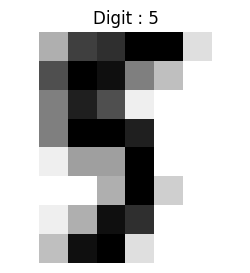

Epoch : 1 | Loss : 2.4062 | Accuracy : 0.1255
Epoch : 2 | Loss : 2.3347 | Accuracy : 0.1425
Epoch : 3 | Loss : 2.2709 | Accuracy : 0.1819
Epoch : 4 | Loss : 2.2134 | Accuracy : 0.2428
Epoch : 5 | Loss : 2.1611 | Accuracy : 0.2732
Epoch : 6 | Loss : 2.1128 | Accuracy : 0.3103
Epoch : 7 | Loss : 2.0677 | Accuracy : 0.3563
Epoch : 8 | Loss : 2.0246 | Accuracy : 0.3957
Epoch : 9 | Loss : 1.9830 | Accuracy : 0.4321
Epoch : 10 | Loss : 1.9424 | Accuracy : 0.4566
Epoch : 11 | Loss : 1.9023 | Accuracy : 0.4811
Epoch : 12 | Loss : 1.8626 | Accuracy : 0.5115
Epoch : 13 | Loss : 1.8229 | Accuracy : 0.5382
Epoch : 14 | Loss : 1.7831 | Accuracy : 0.5672
Epoch : 15 | Loss : 1.7430 | Accuracy : 0.6080
Epoch : 16 | Loss : 1.7026 | Accuracy : 0.6407
Epoch : 17 | Loss : 1.6617 | Accuracy : 0.6719
Epoch : 18 | Loss : 1.6205 | Accuracy : 0.6934
Epoch : 19 | Loss : 1.5790 | Accuracy : 0.7142
Epoch : 20 | Loss : 1.5371 | Accuracy : 0.7283
Epoch : 21 | Loss : 1.4950 | Accuracy : 0.7387
Epoch : 22 | Loss : 1.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical

# TensorFlow Basic Operations

x = tf.constant(5)
y = tf.constant(7)

sum_value = x + y

print("Value of x :", x)
print("Value of y :", y)
print("Addition Result :", sum_value)

# Matrix Example

matrix_1 = tf.constant([[1, 2], [3, 4]], dtype=tf.float32)

print("\nMatrix:")
print(matrix_1)

print("\nMatrix in NumPy Format:")
print(matrix_1.numpy())

vector = tf.Variable([2, 1], dtype=tf.float32)

print("\nVector:")
print(vector)

column_vector = tf.reshape(vector, (2, 1))

print("\nReshaped Vector:")
print(column_vector)

matrix_result = tf.matmul(matrix_1, column_vector)

print("\nMatrix Multiplication Output:")
print(matrix_result)

# Load Digit Dataset

digit_dataset = load_digits()

features = digit_dataset.data
labels = digit_dataset.target

# Display Sample Digit

sample_img = 15

plt.figure(figsize=(3, 3))
plt.imshow(digit_dataset.images[sample_img], cmap='binary')
plt.title(f"Digit : {digit_dataset.target[sample_img]}")
plt.axis("off")
plt.show()

# Split Dataset

x_train, x_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.25,
    random_state=12
)

# Normalize Data

scaling = MinMaxScaler()

x_train = scaling.fit_transform(x_train)
x_test = scaling.transform(x_test)

# One Hot Encoding

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Convert into Tensors

x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
x_test = tf.convert_to_tensor(x_test, dtype=tf.float32)

y_train_cat = tf.convert_to_tensor(y_train_cat, dtype=tf.float32)
y_test_cat = tf.convert_to_tensor(y_test_cat, dtype=tf.float32)

# Initialize Neural Network Parameters

initializer = tf.keras.initializers.HeNormal()

weight_1 = tf.Variable(initializer(shape=(64, 128)))
bias_1 = tf.Variable(tf.zeros([128]))

weight_2 = tf.Variable(initializer(shape=(128, 64)))
bias_2 = tf.Variable(tf.zeros([64]))

weight_3 = tf.Variable(initializer(shape=(64, 10)))
bias_3 = tf.Variable(tf.zeros([10]))

# Neural Network Function

def model_forward(data):

    layer1 = tf.matmul(data, weight_1) + bias_1
    activation1 = tf.nn.relu(layer1)

    layer2 = tf.matmul(activation1, weight_2) + bias_2
    activation2 = tf.nn.relu(layer2)

    final_layer = tf.matmul(activation2, weight_3) + bias_3

    return final_layer

# Loss Calculation

def loss_function(predicted_output, actual_output):

    error = tf.reduce_mean(
        tf.nn.softmax_cross_entropy_with_logits(
            labels=actual_output,
            logits=predicted_output
        )
    )

    return error

# Optimizer

adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Model Training

total_epochs = 25

for i in range(total_epochs):

    with tf.GradientTape() as tape:

        output_logits = model_forward(x_train)

        training_loss = loss_function(
            output_logits,
            y_train_cat
        )

    trainable_variables = [
        weight_1, bias_1,
        weight_2, bias_2,
        weight_3, bias_3
    ]

    gradients = tape.gradient(
        training_loss,
        trainable_variables
    )

    adam_optimizer.apply_gradients(
        zip(gradients, trainable_variables)
    )

    predicted_class = tf.argmax(output_logits, axis=1)
    original_class = tf.argmax(y_train_cat, axis=1)

    train_accuracy = tf.reduce_mean(
        tf.cast(predicted_class == original_class, tf.float32)
    )

    print(
        f"Epoch : {i+1} | Loss : {training_loss.numpy():.4f} | Accuracy : {train_accuracy.numpy():.4f}"
    )

# Model Testing

test_output = model_forward(x_test)

predicted_test = tf.argmax(test_output, axis=1)
actual_test = tf.argmax(y_test_cat, axis=1)

final_accuracy = tf.reduce_mean(
    tf.cast(predicted_test == actual_test, tf.float32)
)

print("\nFinal Test Accuracy :", final_accuracy.numpy())